In [1]:
#67 sampels per words
#4 words total
#FRAMES = 24
#FEATURES_PER_FRAME = 195

In [1]:

import os
import json
import zipfile
import shutil
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

FRAMES = 24
FEATURES_PER_FRAME = 195

DATASET_DIR = "/content/dataset/phrases"
OUTPUT_DIR = "/content/output"
MODEL_PATH = f"{OUTPUT_DIR}/phrase_lstm.keras"
LABELS_PATH = f"{OUTPUT_DIR}/phrase_labels.json"

os.makedirs(OUTPUT_DIR, exist_ok=True)

TensorFlow version: 2.19.0


In [5]:
# =========================
# Upload + unzip dataset properly
# =========================

from google.colab import files
import zipfile
import os
import shutil

# Upload file manually
uploaded = files.upload()

# Get uploaded file name
zip_name = list(uploaded.keys())[0]
zip_path = f"/content/{zip_name}"

# Clean old dataset if exists
if os.path.exists("/content/dataset"):
    shutil.rmtree("/content/dataset")

os.makedirs("/content/dataset", exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall("/content/dataset")

print("Extracted to /content/dataset")

Saving dataset.zip to dataset (1).zip
Extracted to /content/dataset


In [6]:
# =========================
# Auto-detect correct phrases folder
# =========================

def find_phrases_dir(base="/content/dataset"):
    for root, dirs, files in os.walk(base):
        if root.endswith("phrases"):
            return root
    return None

DATASET_DIR = find_phrases_dir()

print("Detected dataset path:", DATASET_DIR)

if DATASET_DIR is None:
    raise Exception("❌ 'phrases' folder not found inside dataset")

Detected dataset path: /content/dataset/phrases


In [7]:
print(os.listdir(DATASET_DIR))

['thank_you', 'hello', 'my', 'name']


In [8]:
# =========================
# 3) Load dataset
# =========================

def load_dataset(dataset_dir, expected_frames=FRAMES, expected_features=FEATURES_PER_FRAME):
    x_data = []
    y_data = []
    label_names = []

    phrase_dirs = sorted([p for p in Path(dataset_dir).iterdir() if p.is_dir()])
    label_names = [p.name for p in phrase_dirs]
    label_to_index = {label: idx for idx, label in enumerate(label_names)}

    skipped = []

    for phrase_dir in phrase_dirs:
        phrase_name = phrase_dir.name
        for npy_file in sorted(phrase_dir.glob("*.npy"), key=lambda p: int(p.stem) if p.stem.isdigit() else p.stem):
            try:
                arr = np.load(npy_file)
            except Exception as e:
                skipped.append((str(npy_file), f"load_error: {e}"))
                continue

            if arr.shape != (expected_frames, expected_features):
                skipped.append((str(npy_file), f"bad_shape: {arr.shape}"))
                continue

            x_data.append(arr.astype(np.float32))
            y_data.append(label_to_index[phrase_name])

    x_data = np.asarray(x_data, dtype=np.float32)
    y_data = np.asarray(y_data, dtype=np.int32)

    return x_data, y_data, label_names, skipped


X, y, label_names, skipped = load_dataset(DATASET_DIR)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", label_names)
print("Skipped files:", len(skipped))

if skipped[:10]:
    print("First skipped examples:")
    for item in skipped[:10]:
        print(item)

X shape: (268, 24, 195)
y shape: (268,)
Labels: ['hello', 'my', 'name', 'thank_you']
Skipped files: 0


In [9]:
# =========================
# 4) Quick class counts
# =========================

for idx, name in enumerate(label_names):
    count = int(np.sum(y == idx))
    print(f"{name}: {count}")

hello: 67
my: 67
name: 67
thank_you: 67


In [10]:
# =========================
# 5) Train/val/test split
# =========================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (187, 24, 195) (187,)
Val:   (40, 24, 195) (40,)
Test:  (41, 24, 195) (41,)


In [11]:
# =========================
# 6) Build model
# =========================

num_classes = len(label_names)

model = keras.Sequential([
    keras.layers.Input(shape=(FRAMES, FEATURES_PER_FRAME)),
    keras.layers.Masking(mask_value=0.0),

    keras.layers.Bidirectional(
        keras.layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.0)
    ),
    keras.layers.LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.0),

    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.30),
    keras.layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 24, 195)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 128)        │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,948 (730.27 KB)

 Trainable params: 186,948 (730.27 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# =========================
# 7) Callbacks
# =========================

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [13]:
# =========================
# 8) Train
# =========================

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=16,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

Epoch 1/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3918 - loss: 1.2581
Epoch 1: val_loss improved from None to 0.68005, saving model to /content/output/phrase_lstm.keras

Epoch 1: finished saving model to /content/output/phrase_lstm.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.5668 - loss: 1.1100 - val_accuracy: 0.9000 - val_loss: 0.6801 - learning_rate: 0.0010
Epoch 2/80
 7/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8267 - loss: 0.7024
Epoch 2: val_loss improved from 0.68005 to 0.24801, saving model to /content/output/phrase_lstm.keras

Epoch 2: finished saving model to /content/output/phrase_lstm.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8824 - loss: 0.5784 - val_accuracy: 0.9750 - val_loss: 0.2480 - learning_rate: 0.0010
Epoch 3/80
 7/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9365 - loss: 0.2853
Epoch 3: val_loss improved from 0.24801 to 0.13559, saving model to /content/output/phrase_lstm.keras

Epoch 3: finished savin

In [14]:
# =========================
# 9) Evaluate
# =========================

best_model = keras.models.load_model(MODEL_PATH)

test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", round(float(test_loss), 4))
print("Test accuracy:", round(float(test_acc), 4))

Test loss: 0.0635
Test accuracy: 0.9756


In [15]:
# =========================
# 10) Detailed report
# =========================

y_prob = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=label_names))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

       hello       1.00      1.00      1.00        10
          my       1.00      1.00      1.00        10
        name       1.00      0.91      0.95        11
   thank_you       0.91      1.00      0.95        10

    accuracy                           0.98        41
   macro avg       0.98      0.98      0.98        41
weighted avg       0.98      0.98      0.98        41

Confusion matrix:
[[10  0  0  0]
 [ 0 10  0  0]
 [ 0  0 10  1]
 [ 0  0  0 10]]


In [16]:
# =========================
# 11) Save label map
# Must match inference side
# =========================

label_map = {label: idx for idx, label in enumerate(label_names)}

with open(LABELS_PATH, "w", encoding="utf-8") as f:
    json.dump(label_map, f, indent=2)

print("Saved label map to:", LABELS_PATH)
print(label_map)

Saved label map to: /content/output/phrase_labels.json
{'hello': 0, 'my': 1, 'name': 2, 'thank_you': 3}


In [17]:
# =========================
# 12) Sanity check one prediction
# =========================

sample = X_test[0:1]
pred = best_model.predict(sample, verbose=0)[0]
pred_idx = int(np.argmax(pred))
pred_label = label_names[pred_idx]
pred_conf = float(pred[pred_idx])

print("Predicted:", pred_label)
print("Confidence:", round(pred_conf, 4))
print("True label:", label_names[int(y_test[0])])

Predicted: hello
Confidence: 0.9983
True label: hello


In [18]:
# =========================
# 13) Pack outputs for download
# =========================

EXPORT_ZIP = "/content/asl_model_export.zip"

with zipfile.ZipFile(EXPORT_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(MODEL_PATH, arcname="phrase_lstm.keras")
    zf.write(LABELS_PATH, arcname="phrase_labels.json")

print("Created:", EXPORT_ZIP)

Created: /content/asl_model_export.zip


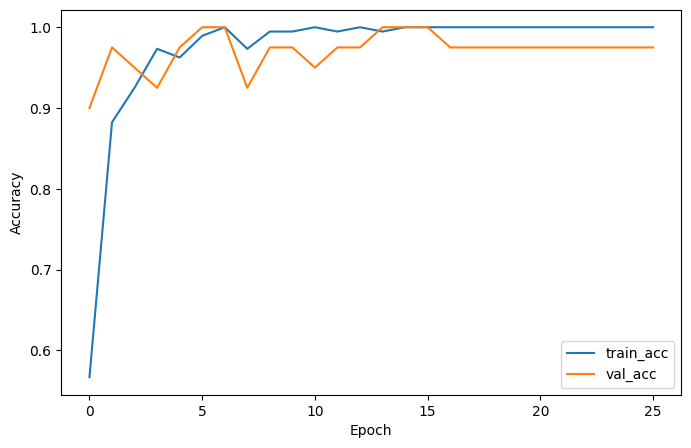

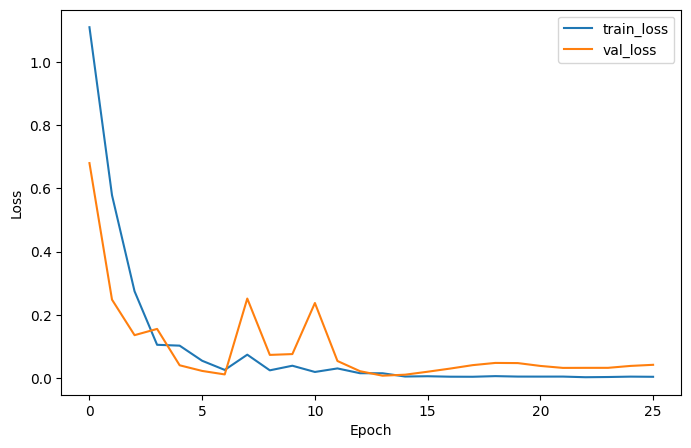

In [19]:
# =========================
# 14) Optional training curves
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()